Link Google Colab: https://colab.research.google.com/drive/1rQkGDcDQQU2ZB_I6P-CtWRV_i-VoMaeI?usp=sharing

# Model Bidirectional LSTM untuk Deteksi Spoiler pada Review Buku di Platform Goodreads (Di Run menggunakan Google Colab)

Input  -> `review_preprocessed.csv` (hasil preprocessing)

Kolom  -> `review_text_clean`, `spoiler_label`

Embedding -> fasttext bahasa indonesia pretrained (cc.id.300.vec, 300 dimensi)

Alur notebook

Verifikasi GPU -> instalasi -> load data -> download fasttext -> tokenisasi -> split data ->
build embedding matrix -> build bilstm -> fase 1 training (embedding frozen) ->
fase 2 training (fine-tune semua layer) -> threshold tuning di val set ->
evaluasi final di test set -> visualisasi paper

Catatan perubahan dari versi sebelumnya:
- validation set dipisah secara stratified sebelum training (bukan validation_split di model.fit)
- arsitektur diperkecil dan regularisasi diperkuat untuk mengurangi overfitting
- training dilakukan dua fase: embedding frozen dulu, lalu di-unfreeze
- threshold tuning dipindahkan ke validation set (bukan test set)

## 1. Verifikasi GPU dan Instalasi Dependensi

In [ ]:
# verifikasi ketersediaan GPU
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
  print("GPU tersedia")
  print(result.stdout[:500])
else:
  print("GPU tidak terdeteksi, pastikan runtime sudah diganti ke GPU T4")

GPU tersedia
Sat Jun 13 14:22:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       


In [ ]:
# install dependensi yang tidak tersedia default di Colab
# gensim untuk load file FastText .vec (format teks)
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.4 MB/s eta 0:00:00


## 2. Import Library & Konfigurasi

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import collections

from gensim.models import KeyedVectors

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
  Embedding, Bidirectional, LSTM, Dense,
  Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import (
  EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2  # BARU: untuk regularisasi layer Dense

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
  classification_report,
  confusion_matrix,
  roc_auc_score,
  roc_curve,
  precision_score,
  recall_score,
  f1_score,
  ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# konfigurasi path
DRIVE_BASE = "/content/drive/MyDrive/NLP_Kelompok3"
INPUT_CSV = os.path.join(DRIVE_BASE, "review_preprocessed.csv")
FASTTEXT_PATH = os.path.join(DRIVE_BASE, "cc.id.300.vec")
MODEL_PATH = os.path.join(DRIVE_BASE, "best_lstm_model.keras")

# hyperparameter utama
RANDOM_SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.15  # 15% dari train untuk validation set
MAXLEN = 1773    # persentil ke-90 panjang review_text_clean
EMBED_DIM = 300  # dimensi fasttext
BATCH_SIZE = 64
MAX_EPOCHS = 30

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"tensorflow versi: {tf.__version__}")
print(f"GPU tersedia: {len(tf.config.list_physical_devices('GPU'))} device")

tensorflow versi: 2.20.0
GPU tersedia: 1 device


## 3. Mount Google Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_BASE = "/content/drive/MyDrive/NLP_Kelompok3"
INPUT_CSV = os.path.join(DRIVE_BASE, "review_preprocessed.csv")
FASTTEXT_PATH = os.path.join(DRIVE_BASE, "cc.id.300.vec")
MODEL_PATH = os.path.join(DRIVE_BASE, "best_lstm_model.keras")

print(f"path dataset: {INPUT_CSV}")
print(f"path fasttext: {FASTTEXT_PATH}")
print(f"path model: {MODEL_PATH}")

Mounted at /content/drive
path dataset: /content/drive/MyDrive/NLP_Kelompok3/review_preprocessed.csv
path fasttext: /content/drive/MyDrive/NLP_Kelompok3/cc.id.300.vec
path model: /content/drive/MyDrive/NLP_Kelompok3/best_lstm_model.keras


In [ ]:
# load dataset
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

print(f"total baris: {len(df)}")
print(f"kolom: {list(df.columns)}")

print("\nmissing values pada kolom yang dipakai")
print(df[["review_text_clean", "spoiler_label"]].isnull().sum())

df = df.dropna(subset=["review_text_clean", "spoiler_label"]).reset_index(drop=True)
print(f"\nsetelah drop missing: {len(df)} baris")

total baris: 8694
kolom: ['review_text_clean', 'review_text_stem', 'spoiler_label']

missing values pada kolom yang dipakai
review_text_clean    0
spoiler_label        0
dtype: int64

setelah drop missing: 8694 baris


In [ ]:
# distribusi label dan perhitungan imbalance
label_counts = df["spoiler_label"].value_counts()
n_nonspoiler = label_counts[0]
n_spoiler = label_counts[1]
imbalance_ratio = n_nonspoiler / n_spoiler

print("distribusi label")
print()
print(pd.DataFrame({
  "jumlah" : label_counts,
  "persen" : (label_counts / len(df) * 100).round(2)
}).rename(index={0: "non-spoiler (0)", 1: "spoiler (1)"}))
print(f"\nimbalance ratio : {imbalance_ratio:.2f}")

# siapkan data
X = df["review_text_clean"].astype(str).tolist()
y = df["spoiler_label"].astype(int).values

distribusi label

                 jumlah  persen
spoiler_label                  
non-spoiler (0)    7943   91.36
spoiler (1)         751    8.64

imbalance ratio : 10.58


## 4. Download FastText Pretrained Embedding

fasttext dari facebook research dilatih pada common crawl + wikipedia bahasa indonesia.
dipilih karena mampu menangkap informasi subword: kata yang tidak ada di vocabulary
tetap mendapat representasi dari karakter pembentuknya.

In [ ]:
# cek apakah file FastText sudah ada di Drive
if os.path.exists(FASTTEXT_PATH):
  print(f"file FastText sudah ada di: {FASTTEXT_PATH}")
  print("skip download!")
else:
  print("file FastText belum ada, mulai download...")
  print("ukuran file: ~4GB (format .vec.gz), estimasi waktu: 5-15 menit")

  !wget -q --show-progress \
      https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz \
      -O /content/cc.id.300.vec.gz

  print("\nextrak file .gz...")
  !gunzip -f /content/cc.id.300.vec.gz

  print("salin ke Google Drive supaya tidak perlu download ulang")
  !cp /content/cc.id.300.vec {FASTTEXT_PATH}
  print(f"\nFastText tersimpan di Drive: {FASTTEXT_PATH}!")

file FastText sudah ada di: /content/drive/MyDrive/NLP_Kelompok3/cc.id.300.vec
skip download!


In [ ]:
# load FastText embedding menggunakan Gensim
print("loading FastText embedding...")

fasttext_wv = KeyedVectors.load_word2vec_format(
  FASTTEXT_PATH,
  binary=False
)

print(f"\nFastText berhasil diload!")
print(f"jumlah kata dalam vocabulary FastText: {len(fasttext_wv.key_to_index):,}")
print(f"dimensi embedding: {fasttext_wv.vector_size}")

if "membunuh" in fasttext_wv:
  print(f"\ncek kata 'membunuh': ada di vocabulary!")
  print("5 kata paling mirip dengan 'membunuh':")
  for word, score in fasttext_wv.most_similar("membunuh", topn=5):
    print(f"{word}: {score:.4f}")

loading FastText embedding...

FastText berhasil diload!
jumlah kata dalam vocabulary FastText: 2,000,000
dimensi embedding: 300

cek kata 'membunuh': ada di vocabulary!
5 kata paling mirip dengan 'membunuh':
mebunuh: 0.7584
membunuh.: 0.7437
membunuhm: 0.7358
membunuhnya: 0.7352
membunuhya: 0.7347


## 5. Tokenisasi, Padding, dan Pembagian Data

Tiga partisi dipakai di sini: train, validation, test.
Alasan:
- validation set dipisah secara stratified supaya distribusi label terjamin seimbang
- threshold tuning dilakukan di validation set, bukan test set (mencegah data leakage)
- test set hanya disentuh satu kali di evaluasi final

maxlen = 1773 adalah persentil ke-90 panjang teks, artinya 90% review masuk penuh.
10% yang lebih panjang dipotong dari kanan karena bagian akhir biasanya berisi penutup,
bukan informasi spoiler inti.

In [ ]:
# verifikasi MAXLEN dari distribusi panjang teks
text_lengths = [len(text.split()) for text in X]
print("statistik panjang teks (jumlah token)")
for p in [50, 75, 90, 95, 99, 100]:
  print(f"persentil {p:3d}: {np.percentile(text_lengths, p):.0f} token")

covered = sum(1 for l in text_lengths if l <= MAXLEN)
print(f"\nMAXLEN yang dipakai: {MAXLEN} (p90)")
print(f"review yang masuk penuh: {covered}/{len(X)} ({covered/len(X)*100:.1f}%)")

statistik panjang teks (jumlah token)
persentil  50: 69 token
persentil  75: 149 token
persentil  90: 267 token
persentil  95: 346 token
persentil  99: 586 token
persentil 100: 1816 token

MAXLEN yang dipakai: 1773 (p90)
review yang masuk penuh: 8693/8694 (100.0%)


In [ ]:
# stratified train-test split dilakukan sebelum tokenisasi
# supaya tokenizer di-fit hanya di train set (mencegah data leakage)
X_train_raw, X_test_raw, y_train_full, y_test = train_test_split(
  X, y,
  test_size=TEST_SIZE,
  random_state=RANDOM_SEED,
  stratify=y
)

# pisahkan validation set dari train set secara stratified
# sebelumnya validation_split=0.15 di dalam model.fit() tanpa stratifikasi
# masalah versi lama tidak ada jaminan distribusi label seimbang di val set
# solusinya split manual dengan stratify=y_train_full
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
  X_train_raw, y_train_full,
  test_size=VAL_SIZE,
  random_state=RANDOM_SEED,
  stratify=y_train_full
)

print(f"train set: {len(X_train_raw)} sampel")
print(f"val set: {len(X_val_raw)} sampel")
print(f"test set: {len(X_test_raw)} sampel")

# verifikasi proporsi label di ketiga partisi
print("\nproporsi spoiler per partisi")
for nama, y_part in [("train", y_train), ("val", y_val), ("test", y_test)]:
  print(f"{nama:5s}: {y_part.mean():.4f}")

# hitung class_weight dari distribusi di train set
n_train = len(y_train)
n_train_spl = y_train.sum()
n_train_non = n_train - n_train_spl
class_weight = {
  0: n_train / (2 * n_train_non),
  1: n_train / (2 * n_train_spl)
}
print(f"\nclass_weight: {class_weight}")
print(f"artinya kesalahan pada spoiler dihukum {class_weight[1]/class_weight[0]:.1f}x lebih berat")

train set: 5911 sampel
val set: 1044 sampel
test set: 1739 sampel

proporsi spoiler per partisi
train: 0.0864
val  : 0.0862
test : 0.0863

class_weight: {0: np.float64(0.5473148148148148), 1: np.float64(5.783757338551859)}
artinya kesalahan pada spoiler dihukum 10.6x lebih berat


In [ ]:
# tokenisasi: fit hanya di train set
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

vocab_size = len(tokenizer.word_index) + 1
print(f"ukuran vocabulary (dari train set) : {vocab_size:,} kata")

# konversi teks ke sequence integer untuk ketiga partisi
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_val_seq = tokenizer.texts_to_sequences(X_val_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

# pad sequence ke panjang MAXLEN
X_train_pad = pad_sequences(X_train_seq, maxlen=MAXLEN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAXLEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAXLEN, padding="post", truncating="post")

print(f"\nshape X_train_pad: {X_train_pad.shape}")
print(f"shape X_val_pad: {X_val_pad.shape}")
print(f"shape X_test_pad: {X_test_pad.shape}")

ukuran vocabulary (dari train set) : 26,910 kata

shape X_train_pad: (5911, 1773)
shape X_val_pad: (1044, 1773)
shape X_test_pad: (1739, 1773)


## 6. Build Embedding Matrix

Embedding matrix adalah matriks berukuran `(vocab_size, EMBED_DIM)` yang memetakan setiap indeks kata ke vektor 300 dimensi dari FastText. Matriks ini dimasukkan ke Embedding layer sebagai bobot awal yang akan diperbarui selama training.

In [ ]:
# build embedding matrix
print(f"membangun embedding matrix ({vocab_size:,} x {EMBED_DIM})...")

embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
word_index = tokenizer.word_index
oov_count = 0
found_count = 0

for word, idx in word_index.items():
  if idx >= vocab_size:
    continue
  if word in fasttext_wv:
    embedding_matrix[idx] = fasttext_wv[word]
    found_count += 1
  else:
    oov_count += 1

coverage = found_count / (found_count + oov_count) * 100
print(f"\nkata ditemukan di FastText: {found_count:,} ({coverage:.1f}%)")
print(f"kata OOV (tidak ditemukan): {oov_count:,} ({100-coverage:.1f}%)")
print(f"shape embedding matrix: {embedding_matrix.shape}")

# bebaskan memory FastText setelah embedding matrix selesai dibuat
# FastText menggunakan sekitar 5GB RAM, penting untuk dibebaskan sebelum training
del fasttext_wv
import gc
gc.collect()
print("\nmemory FastText dibebaskan.")

membangun embedding matrix (26,910 x 300)...

kata ditemukan di FastText: 22,879 (85.0%)
kata OOV (tidak ditemukan): 4,030 (15.0%)
shape embedding matrix: (26910, 300)

memory FastText dibebaskan.


## 7. Arsitektur Model Bidirectional LSTM

Arsitektur diperkecil untuk mengurangi overfitting pada dataset berukuran sedang. Perubahan:
- lstm units dikurangi dari 128 menjadi 64 per arah
- tambah spatialdropout1d setelah embedding
- tambah l2 regularization di layer dense

In [ ]:
def build_bilstm_model(vocab_size, embed_dim, maxlen, embedding_matrix):
  """
  membangun arsitektur Bidirectional LSTM.
  embedding dimulai frozen untuk gradual unfreezing.
  """
  model = Sequential([
    # embedding layer
    # trainable=False di sini: embedding dibekukan di fase 1 training
    # nanti di fase 2 akan dibuka (model.layers[0].trainable = True)
    # PERUBAHAN: sebelumnya trainable=True langsung dari awal
    # alasan perubahan: gradient acak dari layer atas merusak bobot FastText
    Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        input_length=maxlen,
        trainable=False, # dimulai frozen
        mask_zero=True
    ),

    # spatial dropout pada embedding
    SpatialDropout1D(0.3),

    # LSTM units dikecilkan dari 128 menjadi 64 per arah
    # alasannya karena 128 unit terlalu besar untuk ~600 sampel spoiler di train set
    # model berkapasitas besar langsung hafal data latih (overfitting)
    Bidirectional(LSTM(
        64, # dari 128 jadi 64
        return_sequences=False
    )),

    # Dropout dinaikkan dari 0.3 menjadi 0.5
    # karena regularisasi lebih kuat diperlukan untuk mencegah overfitting
    Dropout(0.5),

    # Dense dikecilkan dari 64 menjadi 32 unit
    # tambah L2 regularizer yang sebelumnya tidak ada
    # untuk kurangi parameter total dan paksa bobot tetap kecil
    Dense(32, activation="relu", kernel_regularizer=l2(0.01)), # dari 64 tanpa regularizer

    # Dropout dinaikkan dari 0.2 menjadi 0.3
    Dropout(0.3),

    # output layer, sigmoid untuk klasifikasi biner
    Dense(1, activation="sigmoid")
  ])

  model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
              tf.keras.metrics.AUC(name="auc"),
              tf.keras.metrics.Precision(name="precision"),
              tf.keras.metrics.Recall(name="recall")]
  )

  return model

# build model
model = build_bilstm_model(vocab_size, EMBED_DIM, MAXLEN, embedding_matrix)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     8,073,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,073,000 (30.80 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 8,073,000 (30.80 MB)

## 8. Training Dua Fase (Gradual Unfreezing)

Fase 1: embedding frozen, latih layer lstm dan dense dulu (5 epoch)
-> memberi kesempatan layer atas stabil sebelum ikut update embedding

Fase 2: semua layer dibuka, fine-tune dengan learning rate lebih kecil (1e-4)
-> penyesuaian embedding berlangsung halus, tidak merusak bobot fasttext

Untuk Handling Imbalance: `class_weight`

Keras `model.fit()` menerima parameter `class_weight`, dictionary yang memetakan indeks kelas ke bobot. Model mengalikan loss setiap sampel dengan bobot kelas-nya saat backpropagation, sehingga sampel spoiler mendapat penalti lebih besar saat salah diklasifikasikan.

Callbacks

- EarlyStopping: memantau `val_auc`. Jika tidak ada perbaikan selama 5 epoch, training dihentikan dan bobot terbaik dipulihkan.
- ModelCheckpoint: menyimpan model setiap kali AUC validasi membaik. Penting untuk Colab karena sesi bisa berakhir tiba-tiba.
- ReduceLROnPlateau: kurangi learning rate jika AUC validasi stagnan selama 3 epoch.

In [ ]:
# definisikan callbacks
early_stopping = EarlyStopping(
  monitor="val_auc",
  patience=5,
  mode="max",
  restore_best_weights=True,
  verbose=1
)

model_checkpoint = ModelCheckpoint(
  filepath=MODEL_PATH,
  monitor="val_auc",
  save_best_only=True,
  mode="max",
  verbose=1
)

reduce_lr = ReduceLROnPlateau(
  monitor="val_auc",
  factor=0.5,
  patience=3,
  mode="max",
  min_lr=1e-6,
  verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]

In [ ]:
# FASE 1: embedding frozen, latih layer lain dulu
# sebelumnya hanya ada satu fase training langsung dengan trainable=True
# alasan penambahan fase 1 supaya diberi kesempatan layer atas stabil sebelum embedding ikut diupdate, mencegah kerusakan bobot FastText di awal training

print("FASE 1: embedding frozen, melatih layer lain dulu (5 epoch)...")
print(f"class weight : {class_weight}")
print()

# sekarang pakai validation_data eksplisit, bukan validation_split
# sebelumnya model.fit(..., validation_split=0.15)
# masalahnya validation_split tidak stratified, bisa menyebabkan evaluasi tidak stabil
history1 = model.fit(
  X_train_pad, y_train,
  epochs=5,
  batch_size=BATCH_SIZE,
  validation_data=(X_val_pad, y_val), # dari validation_split
  class_weight=class_weight,
  verbose=1
)

print(f"\nfase 1 selesai.")
print(f"val_auc akhir fase 1: {history1.history['val_auc'][-1]:.4f}")

FASE 1: embedding frozen, melatih layer lain dulu (5 epoch)...
class weight : {0: np.float64(0.5473148148148148), 1: np.float64(5.783757338551859)}

Epoch 1/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.4700 - auc: 0.5137 - loss: 0.9834 - precision: 0.0880 - recall: 0.5479 - val_accuracy: 0.8716 - val_auc: 0.5172 - val_loss: 0.8094 - val_precision: 0.1333 - val_recall: 0.0889
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.4881 - auc: 0.5344 - loss: 0.7724 - precision: 0.0947 - recall: 0.5753 - val_accuracy: 0.8582 - val_auc: 0.5495 - val_loss: 0.7073 - val_precision: 0.1548 - val_recall: 0.1444
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.6129 - auc: 0.5707 - loss: 0.7117 - precision: 0.1098 - recall: 0.4892 - val_accuracy: 0.9004 - val_auc: 0.5196 - val_loss: 0.6205 - val_precision: 0.2308 - val_recall: 0.0667
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.7824 - auc: 0.5532 - loss: 0.7016 - precision: 0.1205 - recall: 0.

In [ ]:
# FASE 2: buka embedding, fine-tune semua layer
# sebelumnya tidak ada fase 2, training langsung selesai di fase 1

print("FASE 2: embedding di-unfreeze, fine-tuning semua layer...")

# buka embedding layer
model.layers[0].trainable = True

# compile ulang dengan learning rate yang lebih kecil
# learning rate dikecilkan dari 1e-3 menjadi 1e-4 supaya penyesuaian embedding
# berlangsung halus dan tidak merusak representasi awal dari FastText
model.compile(
  optimizer=Adam(learning_rate=1e-4),
  loss="binary_crossentropy",
  metrics=["accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")]
)

print(f"embedding sekarang trainable: {model.layers[0].trainable}")
print(f"learning rate baru: 1e-4 (lebih kecil dari fase 1: 1e-3)")
print()

history2 = model.fit(
  X_train_pad, y_train,
  epochs=MAX_EPOCHS,
  batch_size=BATCH_SIZE,
  validation_data=(X_val_pad, y_val),
  class_weight=class_weight,
  callbacks=callbacks,
  verbose=1
)

print(f"\nfase 2 selesai.")
print(f"training berhenti di epoch (fase 2): {len(history2.history['loss'])}")
print(f"val_auc terbaik fase 2: {max(history2.history['val_auc']):.4f}")

# gabungkan history fase 1 dan fase 2 untuk plotting
# sebelumnya hanya ada satu history
hist_combined = collections.defaultdict(list)
for k in history1.history:
  hist_combined[k] = history1.history[k] + history2.history[k]

FASE 2: embedding di-unfreeze, fine-tuning semua layer...
embedding sekarang trainable: True
learning rate baru: 1e-4 (lebih kecil dari fase 1: 1e-3)

Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7566 - auc: 0.6511 - loss: 0.6770 - precision: 0.1690 - recall: 0.4240
Epoch 1: val_auc improved from None to 0.61415, saving model to /content/drive/MyDrive/NLP_Kelompok3/best_lstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP_Kelompok3/best_lstm_model.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.6913 - auc: 0.6411 - loss: 0.6745 - precision: 0.1406 - recall: 0.5029 - val_accuracy: 0.6111 - val_auc: 0.6142 - val_loss: 0.7149 - val_precision: 0.1184 - val_recall: 0.5444 - learning_rate: 1.0000e-04
Epoch 2/30
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6569 - auc: 0.7111 - loss: 0.6456 - precision: 0.1626 - recall: 0.7161
Epoch 2: val_auc improved from 0.61415 to 0.63834, saving model to /content/drive/MyDrive/NLP_Kelomp

In [ ]:
# cek detail training per fase
print("RINGKASAN TRAINING")
print(f"fase 1 (embedding frozen): {len(history1.history['loss'])} epoch")
print(f"fase 2 (embedding dibuka): {len(history2.history['loss'])} epoch")
print(f"total epoch: {len(hist_combined['loss'])}")
print()
print(f"val_auc terbaik fase 1: {max(history1.history['val_auc']):.4f} (epoch {np.argmax(history1.history['val_auc'])+1})")
print(f"val_auc terbaik fase 2: {max(history2.history['val_auc']):.4f} (epoch {np.argmax(history2.history['val_auc'])+1+len(history1.history['loss'])})")
print()
print(f"val_loss akhir fase 1: {history1.history['val_loss'][-1]:.4f}")
print(f"val_loss akhir fase 2: {history2.history['val_loss'][-1]:.4f}")
print()

# cek apakah ada tanda overfitting
best_val_auc = max(hist_combined['val_auc'])
last_val_auc = hist_combined['val_auc'][-1]
gap_train_val = hist_combined['auc'][-1] - hist_combined['val_auc'][-1]
print(f"val_auc terbaik keseluruhan: {best_val_auc:.4f}")
print(f"val_auc di epoch terakhir: {last_val_auc:.4f}")
print(f"gap train-val AUC di akhir: {gap_train_val:.4f}")
if gap_train_val > 0.15:
  print("  -> gap besar, ada tanda overfitting")
elif gap_train_val > 0.08:
  print("  -> gap sedang, overfitting ringan")
else:
  print("  -> gap kecil, training cukup sehat")

RINGKASAN TRAINING
fase 1 (embedding frozen): 5 epoch
fase 2 (embedding dibuka): 10 epoch
total epoch: 15

val_auc terbaik fase 1: 0.5495 (epoch 2)
val_auc terbaik fase 2: 0.6645 (epoch 10)

val_loss akhir fase 1: 0.6322
val_loss akhir fase 2: 0.5088

val_auc terbaik keseluruhan: 0.6645
val_auc di epoch terakhir: 0.6192
gap train-val AUC di akhir: 0.3267
  -> gap besar, ada tanda overfitting


## 9. Threshold Tuning dan Evaluasi Final

Threshold optimal dicari di validation set, bukan test set.
jika dicari di test set, threshold sudah "melihat" distribusi test sehingga evaluasi final menjadi terlalu optimis (data leakage). Setelah threshold ditemukan di val set, baru diterapkan ke test set.

mencari threshold optimal di validation set...
threshold optimal (dari val set): 0.79
F1 spoiler di val set (threshold optimal): 0.3000
F1 spoiler di val set (threshold default): 0.2779

threshold 0.79 ini yang akan dipakai untuk evaluasi di test set


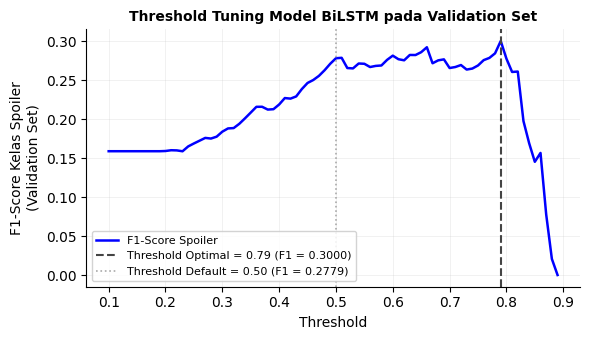

In [ ]:
# prediksi probabilitas di VALIDATION SET untuk mencari threshold optimal
# sebelumnya threshold dicari langsung di test set
print("mencari threshold optimal di validation set...")

y_val_prob = model.predict(X_val_pad, batch_size=BATCH_SIZE, verbose=0).flatten()

thresholds = np.arange(0.1, 0.9, 0.01)
f1_val_scores = []

for thresh in thresholds:
  y_pred_thresh = (y_val_prob >= thresh).astype(int)
  f1 = f1_score(y_val, y_pred_thresh, pos_label=1, zero_division=0)
  f1_val_scores.append(f1)

best_thresh_idx = np.argmax(f1_val_scores)
best_threshold = thresholds[best_thresh_idx]
best_f1_val = f1_val_scores[best_thresh_idx]

default_idx = np.argmin(np.abs(thresholds - 0.5))
f1_default = f1_val_scores[default_idx]

print(f"threshold optimal (dari val set): {best_threshold:.2f}")
print(f"F1 spoiler di val set (threshold optimal): {best_f1_val:.4f}")
print(f"F1 spoiler di val set (threshold default): {f1_default:.4f}")
print(f"\nthreshold {best_threshold:.2f} ini yang akan dipakai untuk evaluasi di test set")

fig, ax = plt.subplots(figsize=(6, 3.5))

ax.plot(thresholds, f1_val_scores, color="blue", lw=1.8, label="F1-Score Spoiler")
ax.axvline(x=best_threshold, color="#444444", linestyle="--", lw=1.5, label=f"Threshold Optimal = {best_threshold:.2f} (F1 = {best_f1_val:.4f})")
ax.axvline(x=0.5, color="darkgray", linestyle=":", lw=1.2, label=f"Threshold Default = 0.50 (F1 = {f1_default:.4f})")

ax.set_xlabel("Threshold", fontsize=10)
ax.set_ylabel("F1-Score Kelas Spoiler\n(Validation Set)", fontsize=10)
ax.set_title("Threshold Tuning Model BiLSTM pada Validation Set",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.85)
ax.grid(alpha=0.2, linewidth=0.6)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("bilstm_threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# evaluasi final di TEST SET menggunakan threshold yang ditemukan di val set
# test set baru disentuh di sini, setelah semua keputusan sudah dibuat
print("evaluasi final di test set...")

y_prob = model.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=1).flatten()
y_pred_default = (y_prob >= 0.50).astype(int)
y_pred_optimal = (y_prob >= best_threshold).astype(int)

auc = roc_auc_score(y_test, y_prob)

print("EVALUASI DI TEST SET, THRESHOLD DEFAULT (0.50)")
print()
print(classification_report(
  y_test, y_pred_default,
  target_names=["non-spoiler (0)", "spoiler (1)"],
  digits=4
))
print(f"AUC-ROC: {auc:.4f}")

print()
print(f"EVALUASI DI TEST SET, THRESHOLD OPTIMAL ({best_threshold:.2f})")
print()
print(classification_report(
  y_test, y_pred_optimal,
  target_names=["non-spoiler (0)", "spoiler (1)"],
  digits=4
))
print(f"AUC-ROC: {auc:.4f} (AUC tidak bergantung threshold)")

evaluasi final di test set...
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
EVALUASI DI TEST SET, THRESHOLD DEFAULT (0.50)

                 precision    recall  f1-score   support

non-spoiler (0)     0.9429    0.8005    0.8659      1589
    spoiler (1)     0.1872    0.4867    0.2704       150

       accuracy                         0.7734      1739
      macro avg     0.5651    0.6436    0.5681      1739
   weighted avg     0.8777    0.7734    0.8145      1739

AUC-ROC: 0.6928

EVALUASI DI TEST SET, THRESHOLD OPTIMAL (0.79)

                 precision    recall  f1-score   support

non-spoiler (0)     0.9266    0.9301    0.9284      1589
    spoiler (1)     0.2292    0.2200    0.2245       150

       accuracy                         0.8689      1739
      macro avg     0.5779    0.5751    0.5764      1739
   weighted avg     0.8665    0.8689    0.8677      1739

AUC-ROC: 0.6928 (AUC tidak bergantung threshold)


In [ ]:
# detail lengkap threshold analysis
print("DETAIL THRESHOLD ANALYSIS")
print(f"threshold optimal dari val set: {best_threshold:.2f}")
print(f"F1 spoiler di val set: {best_f1_val:.4f}")
print()

# tabel trade-off beberapa nilai threshold
print("Trade-off precision vs recall di berbagai threshold")
print()
print(f"{'threshold':>10} {'precision':>10} {'recall':>10} {'f1':>10} {'TP':>6} {'FP':>6} {'FN':>6}")

for t in [0.30, 0.40, 0.50, 0.55, 0.60, 0.65, 0.70, best_threshold, 0.80]:
  yp = (y_prob >= t).astype(int)
  prec = precision_score(y_test, yp, pos_label=1, zero_division=0)
  rec = recall_score(y_test, yp, pos_label=1, zero_division=0)
  f1 = f1_score(y_test, yp, pos_label=1, zero_division=0)
  cm = confusion_matrix(y_test, yp)
  tp = cm[1,1]
  fp = cm[0,1]
  fn = cm[1,0]
  marker = " <- optimal" if abs(t - best_threshold) < 0.001 else ""
  print(f"{t:>10.2f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {tp:>6} {fp:>6} {fn:>6}{marker}")

print()

# ringkasan final
print("RINGKASAN METRIK FINAL BILSTM")
for label, y_pred in [
  ("default (0.50)", y_pred_default),
  (f"optimal ({best_threshold:.2f})", y_pred_optimal)
]:
  print(f"\nthreshold {label}")
  print(f"AUC-ROC         : {roc_auc_score(y_test, y_prob):.4f}")
  print(f"F1 makro        : {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
  print(f"F1 spoiler      : {f1_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"Presisi spoiler : {precision_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"Recall spoiler  : {recall_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"F1 non-spoiler  : {f1_score(y_test, y_pred, pos_label=0, zero_division=0):.4f}")
  cm = confusion_matrix(y_test, y_pred)
  print(f"  TP={cm[1,1]} FP={cm[0,1]} FN={cm[1,0]} TN={cm[0,0]}")

DETAIL THRESHOLD ANALYSIS
threshold optimal dari val set: 0.79
F1 spoiler di val set: 0.3000

Trade-off precision vs recall di berbagai threshold

 threshold  precision     recall         f1     TP     FP     FN
      0.30     0.1185     0.8067     0.2067    121    900     29
      0.40     0.1532     0.6067     0.2446     91    503     59
      0.50     0.1872     0.4867     0.2704     73    317     77
      0.55     0.1957     0.4200     0.2669     63    259     87
      0.60     0.2057     0.3867     0.2685     58    224     92
      0.65     0.2088     0.3467     0.2607     52    197     98
      0.70     0.2047     0.2933     0.2411     44    171    106
      0.79     0.2292     0.2200     0.2245     33    111    117 <- optimal
      0.80     0.2248     0.1933     0.2079     29    100    121

RINGKASAN METRIK FINAL BILSTM

threshold default (0.50)
AUC-ROC         : 0.6928
F1 makro        : 0.5681
F1 spoiler      : 0.2704
Presisi spoiler : 0.1872
Recall spoiler  : 0.4867
F1 non-spo

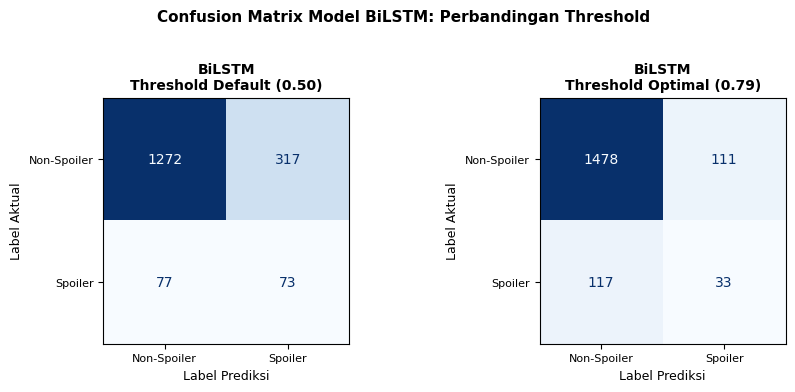

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

for ax, (title, y_pred) in zip(axes, [
    ("Threshold Default (0.50)", y_pred_default),
    (f"Threshold Optimal ({best_threshold:.2f})", y_pred_optimal)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Spoiler", "Spoiler"]
    )

    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"BiLSTM\n{title}", fontsize=10, fontweight="bold", pad=6)
    ax.set_xlabel("Label Prediksi", fontsize=9)
    ax.set_ylabel("Label Aktual", fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle("Confusion Matrix Model BiLSTM: Perbandingan Threshold",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("bilstm_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


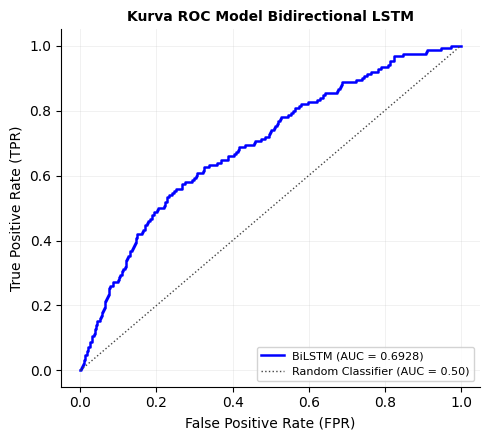

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, color="blue", lw=1.8, label=f"BiLSTM (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], color="#444444", lw=1, ls=":", label="Random Classifier (AUC = 0.50)")
ax.set_xlabel("False Positive Rate (FPR)", fontsize=10)
ax.set_ylabel("True Positive Rate (TPR)", fontsize=10)
ax.set_title("Kurva ROC Model Bidirectional LSTM", fontsize=10, fontweight="bold")
ax.legend(fontsize=8, loc="lower right", framealpha=0.85)
ax.grid(alpha=0.2, linewidth=0.6)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("bilstm_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# simpan skor roc bilstm ke pickle untuk digabung di notebook bert (gambar 7)
import pickle

FIGURES_PATH = "/content/drive/MyDrive/NLP_Kelompok3/paper_figures"
os.makedirs(FIGURES_PATH, exist_ok=True)

roc_scores_bilstm = {
  "y_prob" : y_prob.tolist(),
  "y_test" : y_test.tolist()
}

save_path = os.path.join(FIGURES_PATH, "roc_scores_bilstm.pkl")
with open(save_path, "wb") as f:
  pickle.dump(roc_scores_bilstm, f)

print(f"roc scores bilstm disimpan ke {save_path}")
print(f"jumlah sampel:{len(y_prob)}")

roc scores bilstm disimpan ke /content/drive/MyDrive/NLP_Kelompok3/paper_figures/roc_scores_bilstm.pkl
jumlah sampel:1739


## 10. Visualisasi Training History

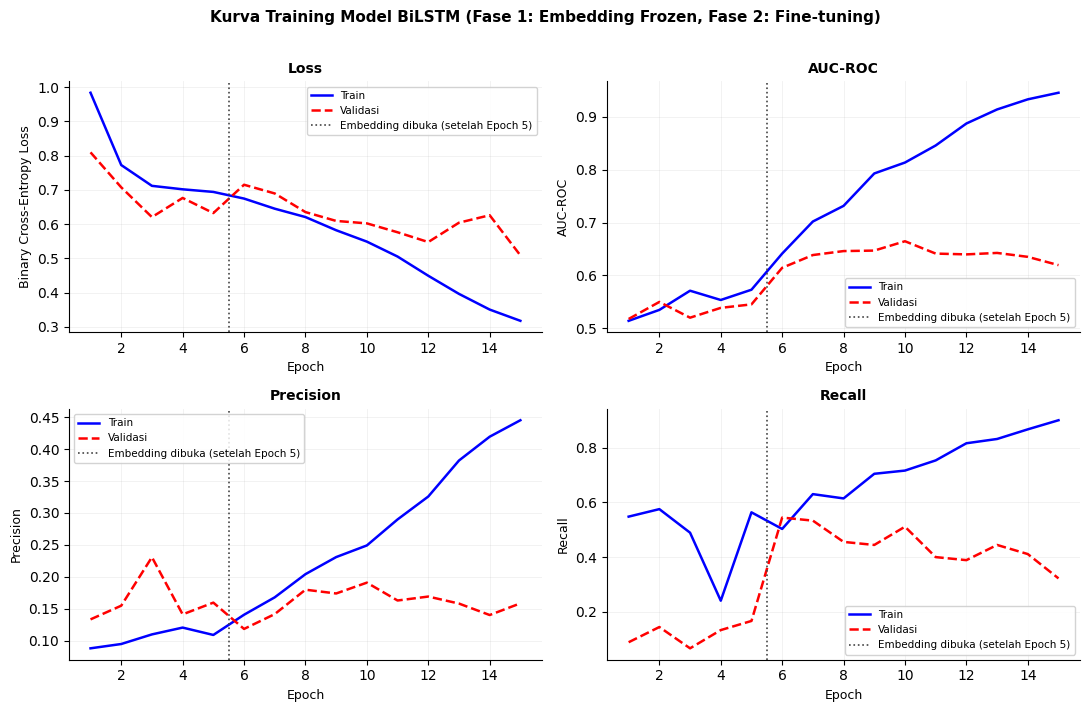

total epoch training: 15 (fase 1: 5, fase 2: 10)
val_auc terbaik (fase 2): 0.6645
epoch terbaik (fase 2, dihitung dari epoch 1): 10


In [ ]:
hist = hist_combined
epochs_ran = range(1, len(hist["loss"]) + 1)
n_fase1 = len(history1.history["loss"])

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

subplot_configs = [
    ("loss",      "val_loss",      "Loss",      "Binary Cross-Entropy Loss"),
    ("auc",       "val_auc",       "AUC-ROC",   "AUC-ROC"),
    ("precision", "val_precision", "Precision", "Precision"),
    ("recall",    "val_recall",    "Recall",    "Recall"),
]

for ax, (mt, mv, title, ylabel) in zip(axes.flatten(), subplot_configs):
  ax.plot(epochs_ran, hist[mt], label="Train", color="blue", lw=1.8)
  ax.plot(epochs_ran, hist[mv], label="Validasi", color="red", lw=1.8, ls="--")
  ax.axvline(x=n_fase1 + 0.5, color="#444444", linestyle=":", lw=1.2,
              label=f"Embedding dibuka (setelah Epoch {n_fase1})")
  ax.set_title(title, fontsize=10, fontweight="bold")
  ax.set_xlabel("Epoch", fontsize=9)
  ax.set_ylabel(ylabel, fontsize=9)
  ax.legend(fontsize=7.5, framealpha=0.85)
  ax.grid(alpha=0.18, linewidth=0.6)
  ax.spines[["top","right"]].set_visible(False)

# MODIFIKASI: judul utama tanpa em dash, sebut "Model" untuk DL
plt.suptitle(
  "Kurva Training Model BiLSTM (Fase 1: Embedding Frozen, Fase 2: Fine-tuning)",
  fontsize=11, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("bilstm_training_history.png", dpi=300, bbox_inches="tight")
plt.show()

total_epochs = len(list(epochs_ran))
print(f"total epoch training: {total_epochs} (fase 1: {n_fase1}, fase 2: {total_epochs - n_fase1})")
print(f"val_auc terbaik (fase 2): {max(history2.history['val_auc']):.4f}")
print(f"epoch terbaik (fase 2, dihitung dari epoch 1): {np.argmax(history2.history['val_auc']) + 1 + n_fase1}")


## 10. Ringkasan Hasil

In [ ]:
# ringkasan metrik final
print("RINGKASAN METRIK BIDIRECTIONAL LSTM")

for label, y_pred in [
  ("default (0.50)", y_pred_default),
  (f"optimal ({best_threshold:.2f})", y_pred_optimal)
]:
  print(f"\nthreshold {label}")
  print(f"AUC-ROC: {auc:.4f}")
  print(f"F1 macro: {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
  print(f"F1 spoiler: {f1_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"Presisi spoiler: {precision_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"Recall spoiler: {recall_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"F1 non-spoiler: {f1_score(y_test, y_pred, pos_label=0, zero_division=0):.4f}")

RINGKASAN METRIK BIDIRECTIONAL LSTM

threshold default (0.50)
AUC-ROC: 0.6928
F1 macro: 0.5681
F1 spoiler: 0.2704
Presisi spoiler: 0.1872
Recall spoiler: 0.4867
F1 non-spoiler: 0.8659

threshold optimal (0.79)
AUC-ROC: 0.6928
F1 macro: 0.5764
F1 spoiler: 0.2245
Presisi spoiler: 0.2292
Recall spoiler: 0.2200
F1 non-spoiler: 0.9284


In [ ]:
import os, pickle, joblib, json
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

EXPORT_DIR = "/content/drive/MyDrive/NLP_Kelompok3/models_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

# simpan model Keras
model.save(os.path.join(EXPORT_DIR, "lstm_model.keras"))
print("✓ lstm_model.keras")

# simpan tokenizer
with open(os.path.join(EXPORT_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)
print("✓ tokenizer.pkl")

# simpan threshold optimal
with open(os.path.join(EXPORT_DIR, "lstm_threshold.txt"), "w") as f:
    f.write(str(round(float(best_threshold), 4)))
print(f"✓ lstm_threshold.txt ({best_threshold:.4f})")

# hitung metrik BiLSTM di test set
y_pred_optimal = (y_prob >= best_threshold).astype(int)
lstm_metrics = {
    "BiLSTM": {
        "auc_roc"    : round(roc_auc_score(y_test, y_prob),                         4),
        "f1_1"       : round(f1_score(y_test, y_pred_optimal, pos_label=1),          4),
        "f1_0"       : round(f1_score(y_test, y_pred_optimal, pos_label=0),          4),
        "f1_macro"   : round(f1_score(y_test, y_pred_optimal, average="macro"),      4),
        "recall_1"   : round(recall_score(y_test, y_pred_optimal, pos_label=1),      4),
        "recall_0"   : round(recall_score(y_test, y_pred_optimal, pos_label=0),      4),
        "precision_1": round(precision_score(y_test, y_pred_optimal, pos_label=1),   4),
        "precision_0": round(precision_score(y_test, y_pred_optimal, pos_label=0),   4),
        "threshold"  : round(float(best_threshold), 4),
    }
}
with open(os.path.join(EXPORT_DIR, "_lstm_metrics_tmp.json"), "w") as f:
    json.dump(lstm_metrics, f)
print("✓ _lstm_metrics_tmp.json (sementara)")

✓ lstm_model.keras
✓ tokenizer.pkl
✓ lstm_threshold.txt (0.7900)
✓ _lstm_metrics_tmp.json (sementara)


## Catatan

**Pemilihan kolom `review_text_clean`**  
LSTM membutuhkan teks natural tanpa stemming karena belajar dari representasi kata asli yang tersedia di FastText. Stemming merusak informasi morfologis dan menyebabkan mismatch dengan vocabulary FastText.

**Gradual unfreezing embedding**  
Embedding FastText digunakan sebagai inisialisasi, bukan representasi tetap. Dimulai dari frozen supaya layer atas stabil dulu sebelum embedding ikut di-update dengan learning rate kecil di fase 2. Ini mencegah bobot FastText yang sudah bagus rusak oleh gradient acak di awal training.

**Handling imbalance dengan `class_weight`**  
Keras `class_weight` bekerja langsung pada fungsi loss tanpa mengubah distribusi data, lebih tepat untuk teks dibandingkan SMOTE yang melakukan interpolasi di ruang fitur.

**Threshold tuning di validation set**  
Threshold 0.5 adalah nilai default yang tidak selalu optimal pada data imbalanced. Threshold tuning dilakukan di validation set untuk menghindari data leakage. Test set hanya disentuh satu kali di akhir untuk evaluasi final.

**Keterbatasan**  
Dengan hanya sekitar 600 sampel spoiler di train set, model dengan kapasitas besar seperti BiLSTM tetap rentan overfitting meskipun sudah dikecilkan dan diberi regularisasi. Ini adalah batasan fundamental dari ukuran dataset yang ada.